<a href="https://colab.research.google.com/github/CodeDanish/Global-Vaccination-Data-Analysis-Visualization-Project/blob/main/Vaccination_Question_Answer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Questions to be answered :**

###Answer the below questions through your analysis and visualizations :

###**Easy Level:**

1. How do vaccination rates correlate with a decrease in disease incidence?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Loading the Data
coverage_clean = pd.read_csv("Coverage_Cleaned_Data.csv")
incidence_rate_clean = pd.read_csv("Incidence_Rate_Cleaned_Data.csv")
reported_cases_clean = pd.read_csv("Reported_Cases_Cleaned_Data.csv")
vacc_intro_clean = pd.read_csv("Vaccine_Introduction_Cleaned_Data.csv")
vacc_sched_clean = pd.read_csv("Vaccine_Schedule_Cleaned_Data.csv")

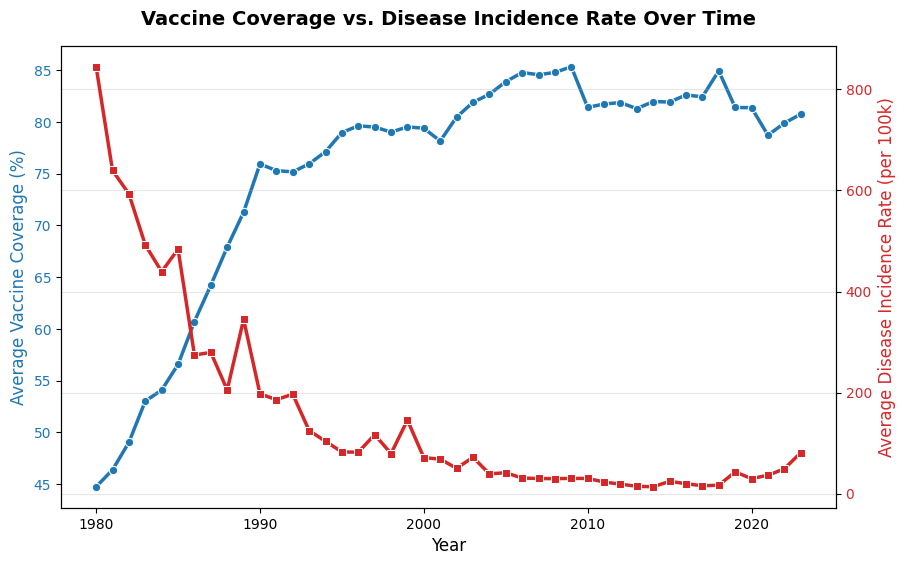

In [2]:
# Aggregating data by year
annual_coverage = coverage_clean.groupby('YEAR')['COVERAGE'].mean().reset_index()
annual_incidence = incidence_rate_clean.groupby('YEAR')['INCIDENCE_RATE'].mean().reset_index()
merged_trend = annual_coverage.merge(annual_incidence, on='YEAR')

fig, ax1 = plt.subplots(figsize=(10, 6))

# Plotting Coverage Rate (Left Axis)
color = '#1f77b4'
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Average Vaccine Coverage (%)', color=color, fontsize=12)
sns.lineplot(data=merged_trend, x='YEAR', y='COVERAGE', ax=ax1, color=color, linewidth=2.5, marker='o')
ax1.tick_params(axis='y', labelcolor=color)

# Creating a second axis for Incidence Rate (Right Axis)
ax2 = ax1.twinx()
color = '#d62728'
ax2.set_ylabel('Average Disease Incidence Rate (per 100k)', color=color, fontsize=12)
sns.lineplot(data=merged_trend, x='YEAR', y='INCIDENCE_RATE', ax=ax2, color=color, linewidth=2.5, marker='s')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Vaccine Coverage vs. Disease Incidence Rate Over Time', fontsize=14, fontweight='bold', pad=15)
plt.grid(True, alpha=0.3)
plt.show()

2. What is the drop-off rate between 1st dose and subsequent doses?

In [3]:
dose_1_data = coverage_clean[coverage_clean['ANTIGEN_DESCRIPTION'].str.contains("1st dose")]
dose_2_data = coverage_clean[coverage_clean['ANTIGEN_DESCRIPTION'].str.contains("2nd dose")]
dose_3_data = coverage_clean[coverage_clean['ANTIGEN_DESCRIPTION'].str.contains("3rd dose")]

dose_1_data.dropna(subset=["COVERAGE"],inplace=True)
dose_2_data.dropna(subset=["COVERAGE"],inplace=True)
dose_3_data.dropna(subset=["COVERAGE"],inplace=True)

dose_1_data["COVERAGE"] = dose_1_data["COVERAGE"].astype("float")
dose_2_data["COVERAGE"] = dose_2_data["COVERAGE"].astype("float")
dose_3_data["COVERAGE"] = dose_3_data["COVERAGE"].astype("float")

print(dose_1_data.shape[0])
print(dose_2_data.shape[0])
print(dose_3_data.shape[0])

63159
13668
73069


/tmp/ipykernel_39997/3128758811.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dose_1_data.dropna(subset=["COVERAGE"],inplace=True)
/tmp/ipykernel_39997/3128758811.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dose_2_data.dropna(subset=["COVERAGE"],inplace=True)
/tmp/ipykernel_39997/3128758811.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dose_3_data.dropna(subset=["COVERAGE"],inplace=True)
/tmp/ipykernel_39997/3128758

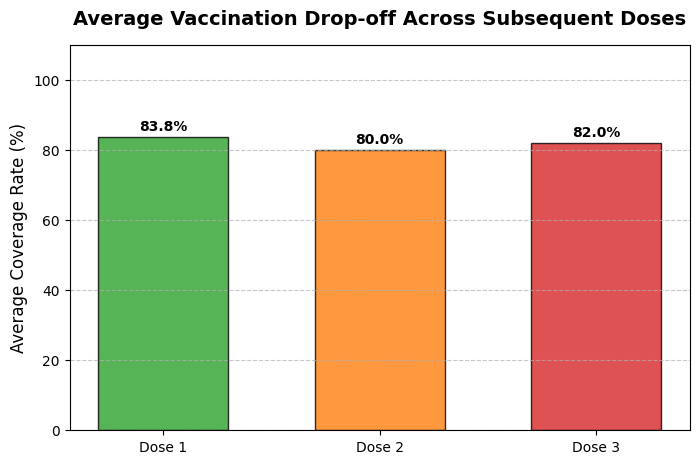

In [4]:
# Assuming columns or rows exist representing Dose 1, Dose 2, Dose 3 averages
# Replace with your actual dose column/filter names if different
doses = ['Dose 1', 'Dose 2', 'Dose 3']
avg_rates = [
    dose_1_data['COVERAGE'].mean(),
    dose_2_data['COVERAGE'].mean(),
    dose_3_data['COVERAGE'].mean()
]

plt.figure(figsize=(8, 5))
colors = ['#2ca02c', '#ff7f0e', '#d62728']
bars = plt.bar(doses, avg_rates, color=colors, width=0.6, edgecolor='black', alpha=0.8)

# Adding value labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 1, f"{yval:.1f}%", ha='center', va='bottom', fontweight='bold')

plt.title('Average Vaccination Drop-off Across Subsequent Doses', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Average Coverage Rate (%)', fontsize=12)
plt.ylim(0, 110)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

3. Are vaccination rates different between genders?

Answer: Genders data is not provided.

4. How does education level impact vaccination rates?

Answer: Education level data is not provided.

5. What is the urban vs. rural vaccination rate difference?

Answer: Location data (Urban/Rural) not provided.

6. Has the rate of booster dose uptake increased over time?

In [5]:
booster_dose_data = coverage_clean[coverage_clean["ANTIGEN_DESCRIPTION"].str.contains("booster")]
print(booster_dose_data.shape[0])

17166


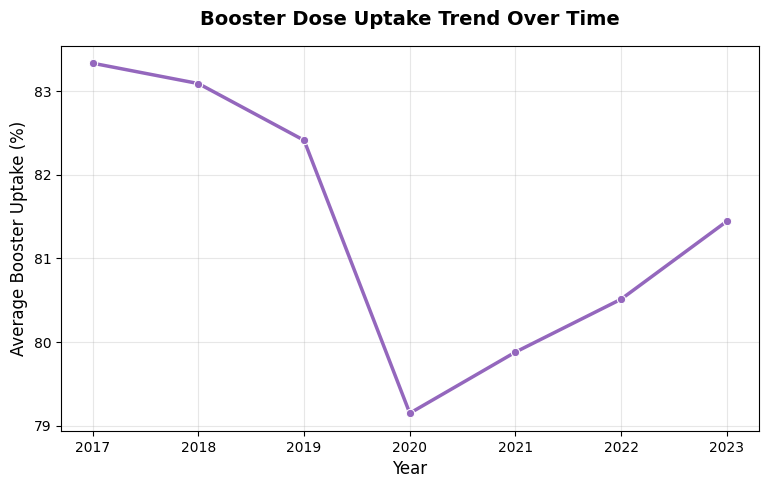

In [6]:
plt.figure(figsize=(9, 5))
# Assuming a 'Booster_Rate' column or specific booster rows exist
# Grouping by Year to get the trend
booster_trend = booster_dose_data.groupby('YEAR')['COVERAGE'].mean().reset_index()

sns.lineplot(data=booster_trend, x='YEAR', y='COVERAGE', color='#9467bd', marker='o', linewidth=2.5)

plt.title('Booster Dose Uptake Trend Over Time', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Booster Uptake (%)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

7. Is there a seasonal pattern in vaccination uptake?

Answer: Seasonal pattern data is not provided.

8. How does population density relate to vaccination coverage?

Answer: Population density data is not provided.

9. Which regions have high disease incidence despite high vaccination rates?

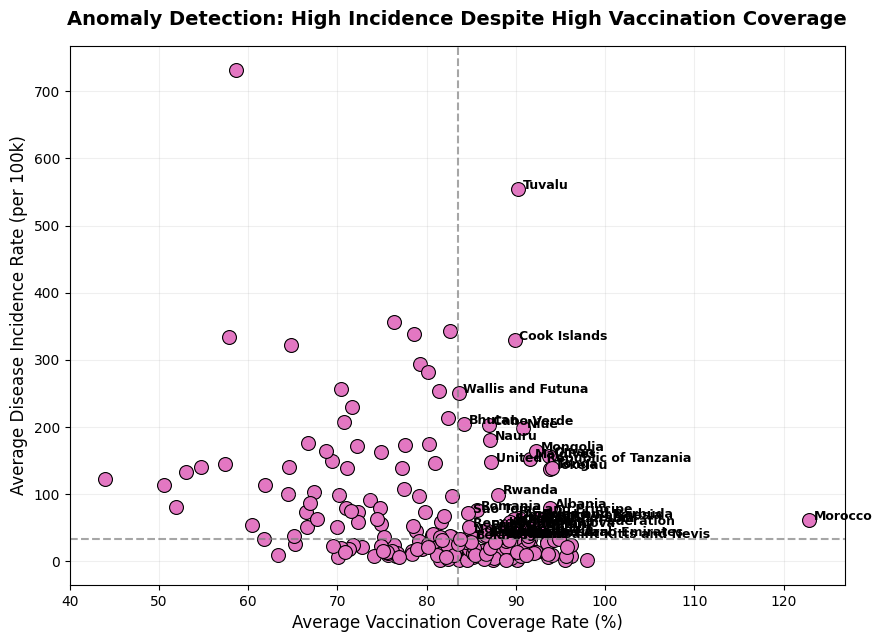

In [7]:
coverage_clean = coverage_clean[coverage_clean['GROUP'] == 'COUNTRIES']
incidence_rate_clean = incidence_rate_clean[incidence_rate_clean['GROUP'] == 'COUNTRIES']

plt.figure(figsize=(10, 7))

# Merging coverage_clean and incidence_rate_clean on "CODE", "YEAR" column
merged_data = pd.merge(coverage_clean, incidence_rate_clean, on=['CODE','NAME','YEAR'], how='left')

# Step 1: Group by Region to find averages
region_summary = merged_data.groupby('NAME').agg({
    'COVERAGE': 'mean',
    'INCIDENCE_RATE': 'mean'
}).reset_index()

# Step 2: Plot
sns.scatterplot(data=region_summary, x='COVERAGE', y='INCIDENCE_RATE', s=100, color='#e377c2', edgecolor='black')

# Step 3: Draw threshold lines to create quadrants (e.g., using median or specific benchmarks)
high_cov_threshold = region_summary['COVERAGE'].median()
high_inc_threshold = region_summary['INCIDENCE_RATE'].median()

plt.axvline(x=high_cov_threshold, color='gray', linestyle='--', alpha=0.7)
plt.axhline(y=high_inc_threshold, color='gray', linestyle='--', alpha=0.7)

# Step 4: Label the outliers in the top-right quadrant (High Coverage, High Incidence)
for i in range(region_summary.shape[0]):
    row = region_summary.iloc[i]
    if row['COVERAGE'] > high_cov_threshold and row['INCIDENCE_RATE'] > high_inc_threshold:
        plt.text(row['COVERAGE'] + 0.5, row['INCIDENCE_RATE'] + 0.5, row['NAME'],
                 fontsize=9, weight='bold', color='black')

plt.title('Anomaly Detection: High Incidence Despite High Vaccination Coverage', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Average Vaccination Coverage Rate (%)', fontsize=12)
plt.ylabel('Average Disease Incidence Rate (per 100k)', fontsize=12)
plt.grid(True, alpha=0.2)
plt.show()

###**Medium level (combination of different tables):**

1. Is there a correlation between vaccine introduction and a decrease in disease cases?

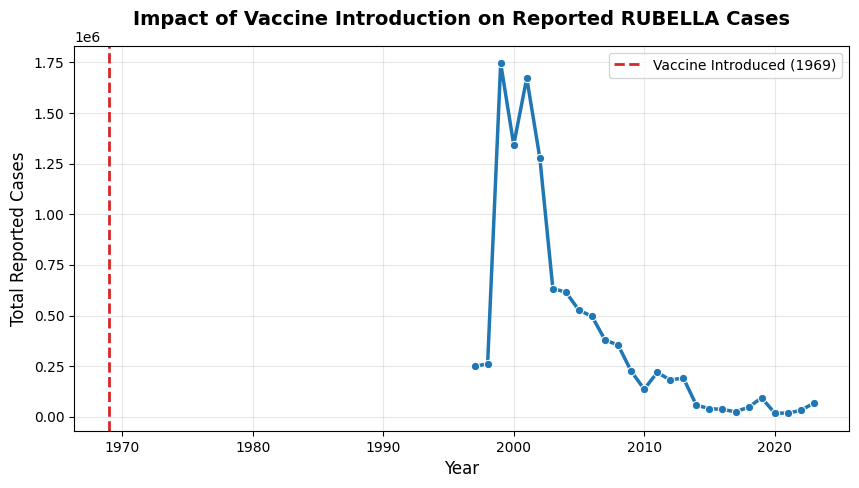

In [8]:
# Merging Introduction Year with Reported Cases data
# Assuming columns: 'Disease', 'Introduction_Year' and 'Year', 'Reported_Cases'
disease_cases = reported_cases_clean.groupby(['DISEASE', 'YEAR'])['CASES'].sum().reset_index()
intro_years = vacc_intro_clean.set_index('DESCRIPTION')['YEAR'].to_dict()

# Example filtering for a specific disease to keep the plot clean, or loop through them
target_disease = disease_cases['DISEASE'].unique()[9]
df_single = disease_cases[disease_cases['DISEASE'] == target_disease]

keys = intro_years.keys()

for key in keys:
  if target_disease.lower() in key.lower():
      target_disease_descrpt = key
  else:
    continue

intro_year = intro_years.get(target_disease_descrpt)

plt.figure(figsize=(10, 5))
sns.lineplot(data=df_single, x='YEAR', y='CASES', marker='o', color='#1f77b4', linewidth=2.5)

# Adding a vertical line showing exactly when the vaccine was introduced
if intro_year:
    plt.axvline(x=intro_year, color='#d62728', linestyle='--', linewidth=2,
                label=f'Vaccine Introduced ({int(intro_year)})')

plt.title(f'Impact of Vaccine Introduction on Reported {target_disease} Cases', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Reported Cases', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

2. What is the trend in disease cases before and after vaccination campaigns?

/tmp/ipykernel_39997/3607257982.py:12: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=merged_campaign, x='DISEASE', y='CASES', hue='Campaign_Era',


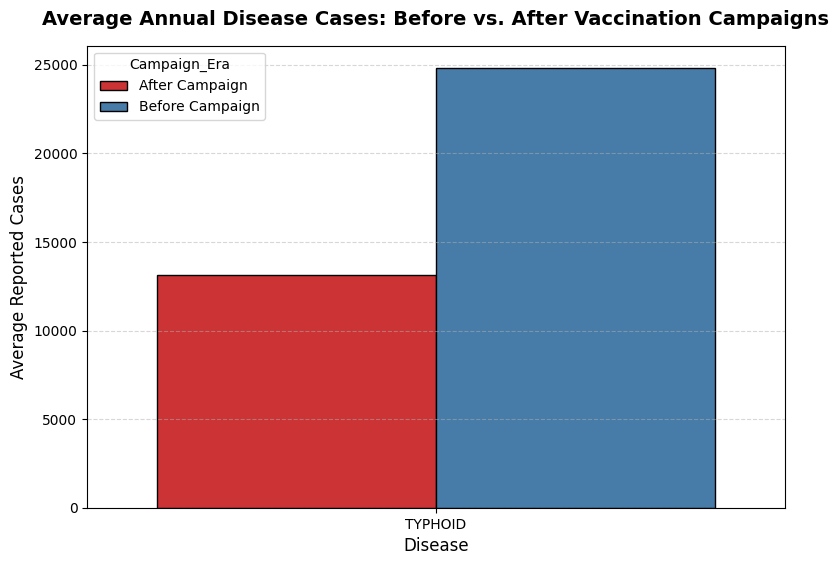

In [9]:
# Merging dataset to match cases with their respective introduction years
merged_campaign = pd.merge(reported_cases_clean, vacc_intro_clean, left_on='DISEASE_DESCRIPTION', right_on='DESCRIPTION', how='inner')

# Creating a categorical era column
merged_campaign['Campaign_Era'] = np.where(
    merged_campaign['YEAR_y'] < merged_campaign['YEAR_x'],
    'Before Campaign',
    'After Campaign'
)

plt.figure(figsize=(9, 6))
sns.barplot(data=merged_campaign, x='DISEASE', y='CASES', hue='Campaign_Era',
            palette='Set1', ci=None, edgecolor='black')

plt.title('Average Annual Disease Cases: Before vs. After Vaccination Campaigns', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Disease', fontsize=12)
plt.ylabel('Average Reported Cases', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

3. Which diseases have shown the most significant reduction in cases due to vaccination?

/tmp/ipykernel_39997/2322921572.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pct_reduction, x='Reduction_Percentage', y='DISEASE', palette='crest', edgecolor='black')


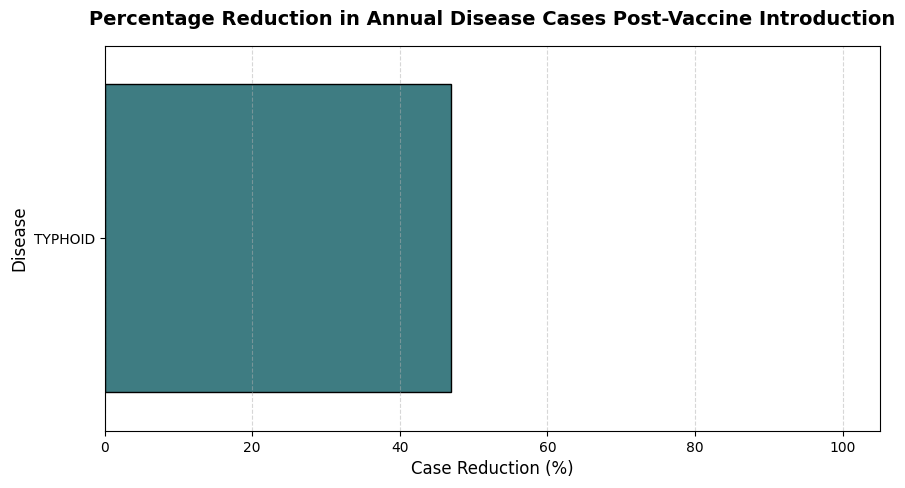

In [10]:
# Calculating pre- and post-introduction averages per disease
pre_avg = merged_campaign[merged_campaign['Campaign_Era'] == 'Before Campaign'].groupby('DISEASE')['CASES'].mean()
post_avg = merged_campaign[merged_campaign['Campaign_Era'] == 'After Campaign'].groupby('DISEASE')['CASES'].mean()

# Percentage reduction calculation
pct_reduction = (((pre_avg - post_avg) / pre_avg) * 100).reset_index(name='Reduction_Percentage')
pct_reduction = pct_reduction.sort_values(by='Reduction_Percentage', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=pct_reduction, x='Reduction_Percentage', y='DISEASE', palette='crest', edgecolor='black')

plt.title('Percentage Reduction in Annual Disease Cases Post-Vaccine Introduction', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Case Reduction (%)', fontsize=12)
plt.ylabel('Disease', fontsize=12)
plt.xlim(0, 105)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

4. What percentage of the target population has been covered by each vaccine?

/tmp/ipykernel_39997/3286061698.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=vaccine_coverage, x='COVERAGE', y='ANTIGEN', palette='viridis', edgecolor='black')


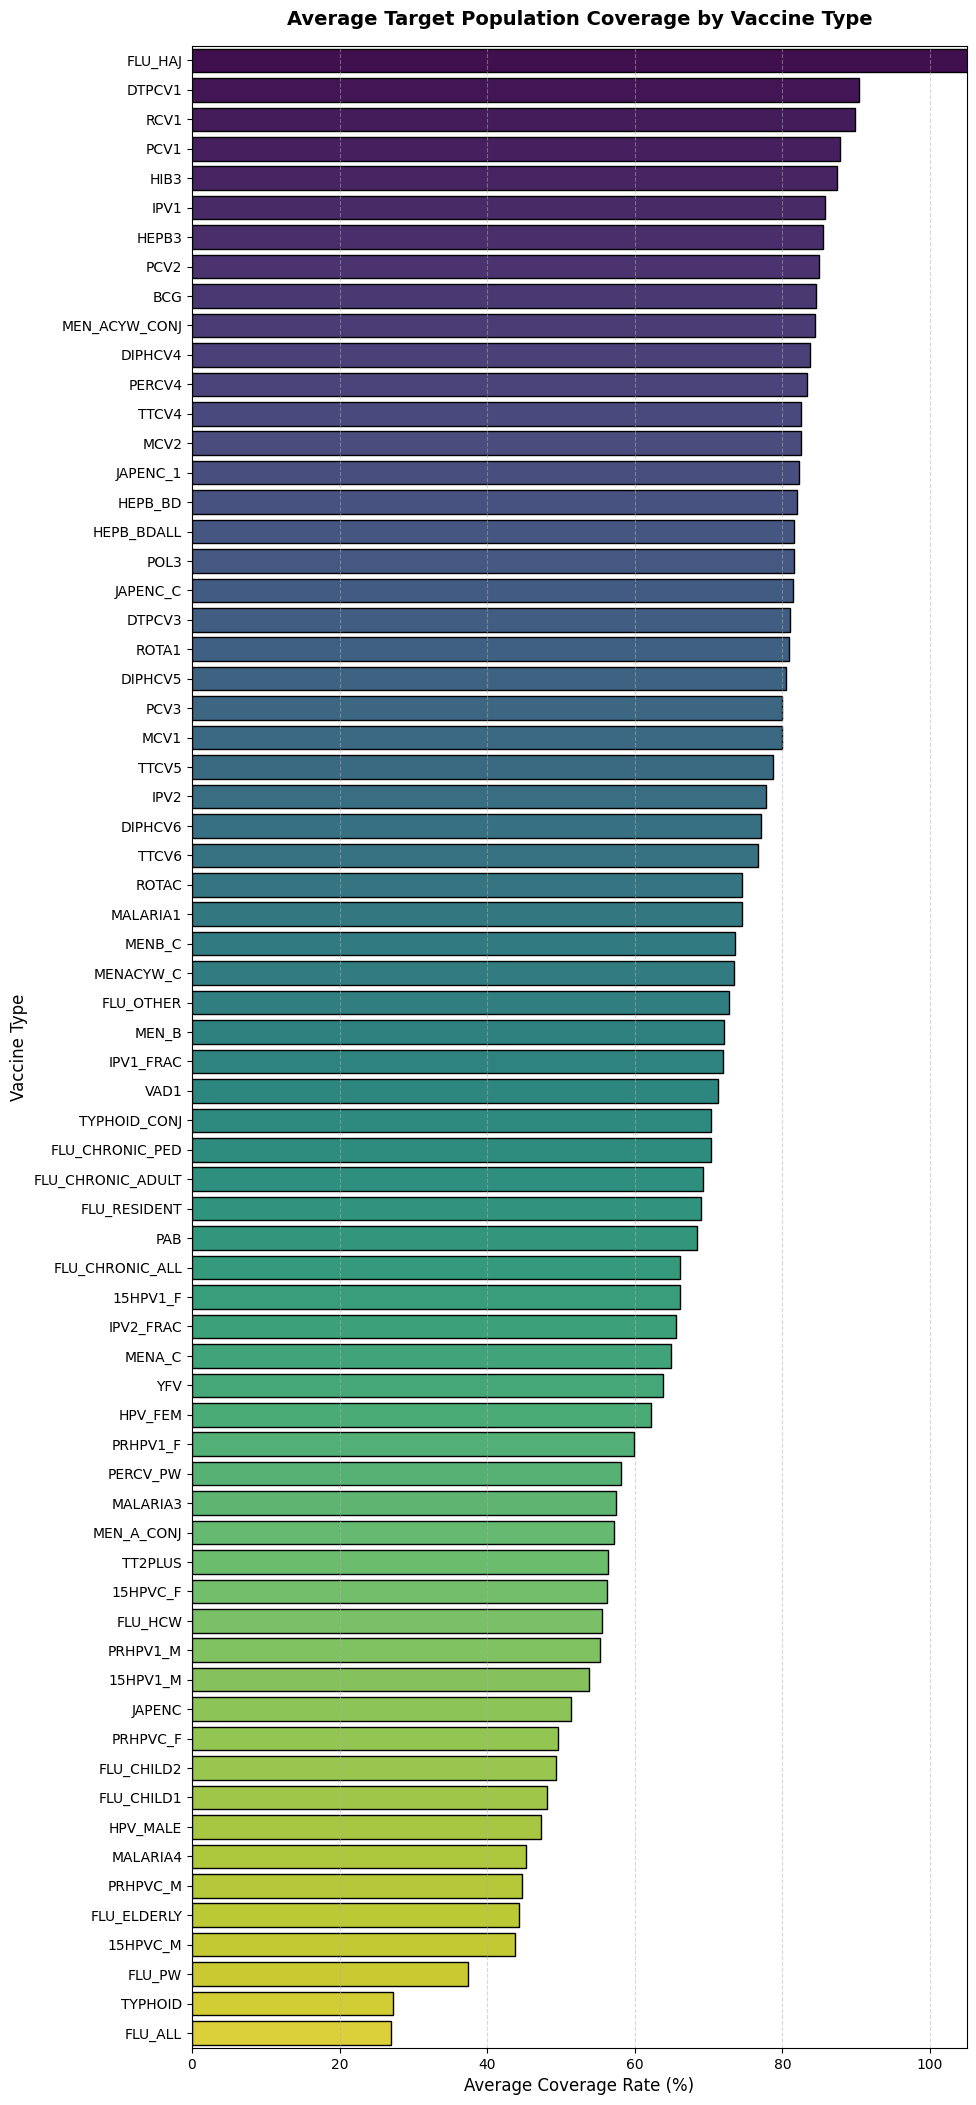

In [11]:
plt.figure(figsize=(10, 26))

# Aggregating overall coverage across years/regions for each vaccine type
vaccine_coverage = coverage_clean.groupby('ANTIGEN')['COVERAGE'].mean().reset_index()
vaccine_coverage = vaccine_coverage.sort_values(by='COVERAGE', ascending=False)

sns.barplot(data=vaccine_coverage, x='COVERAGE', y='ANTIGEN', palette='viridis', edgecolor='black')

plt.title('Average Target Population Coverage by Vaccine Type', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Average Coverage Rate (%)', fontsize=12)
plt.ylabel('Vaccine Type', fontsize=12)
plt.xlim(0, 105)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

5. How does the vaccination schedule (e.g., booster doses) impact target population coverage?

/tmp/ipykernel_39997/813163911.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=schedule_impact, x='DOSES', y='COVERAGE', palette='Accent')


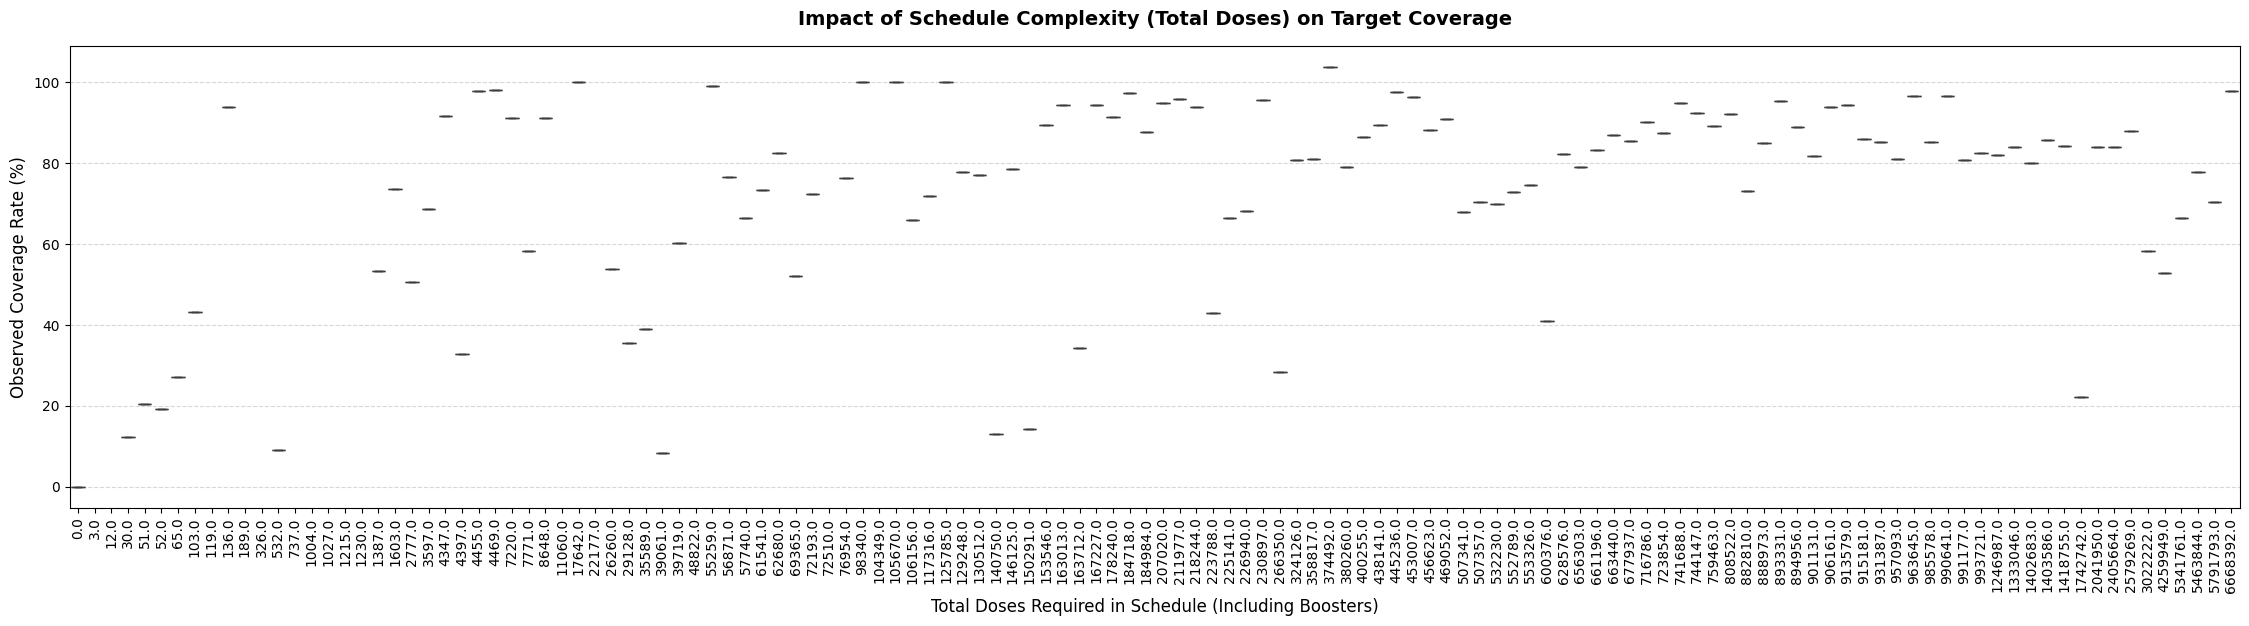

In [12]:
# Merging coverage performance with the scheduled total number of doses required
# Assuming Vaccine_Schedule_Data contains columns: 'Vaccine_Type', 'Total_Doses_Required'
schedule_impact = pd.merge(coverage_clean, vacc_sched_clean, left_on='ANTIGEN_DESCRIPTION', right_on='VACCINE_DESCRIPTION', how='inner')

plt.figure(figsize=(28, 6))
# Using a boxplot to evaluate the distribution of coverage based on dose complexity
sns.boxplot(data=schedule_impact, x='DOSES', y='COVERAGE', palette='Accent')

plt.title('Impact of Schedule Complexity (Total Doses) on Target Coverage', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Total Doses Required in Schedule (Including Boosters)', fontsize=12)
plt.xticks(rotation=90)
plt.ylabel('Observed Coverage Rate (%)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

6. Are there significant disparities in vaccine introduction timelines across WHO regions?

/tmp/ipykernel_39997/1655554479.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=vacc_intro_clean, x='YEAR', y='WHO_REGION',


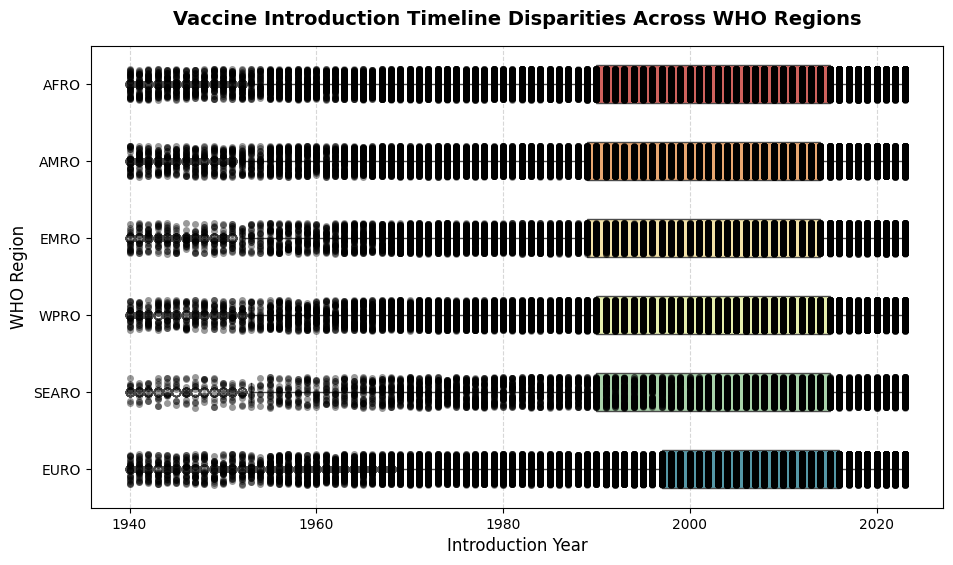

In [13]:
plt.figure(figsize=(11, 6))

# Sorting regions by their median introduction year to show clear timeline shifts
region_order = vacc_intro_clean.groupby('WHO_REGION')['YEAR'].median().sort_values().index

sns.boxplot(data=vacc_intro_clean, x='YEAR', y='WHO_REGION',
            order=region_order, palette='Spectral', width=0.5)
sns.stripplot(data=vacc_intro_clean, x='YEAR', y='WHO_REGION',
              order=region_order, color='black', alpha=0.4, size=5, jitter=0.2)

plt.title('Vaccine Introduction Timeline Disparities Across WHO Regions', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Introduction Year', fontsize=12)
plt.ylabel('WHO Region', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

7. How does vaccine coverage correlate with disease reduction for specific antigens?

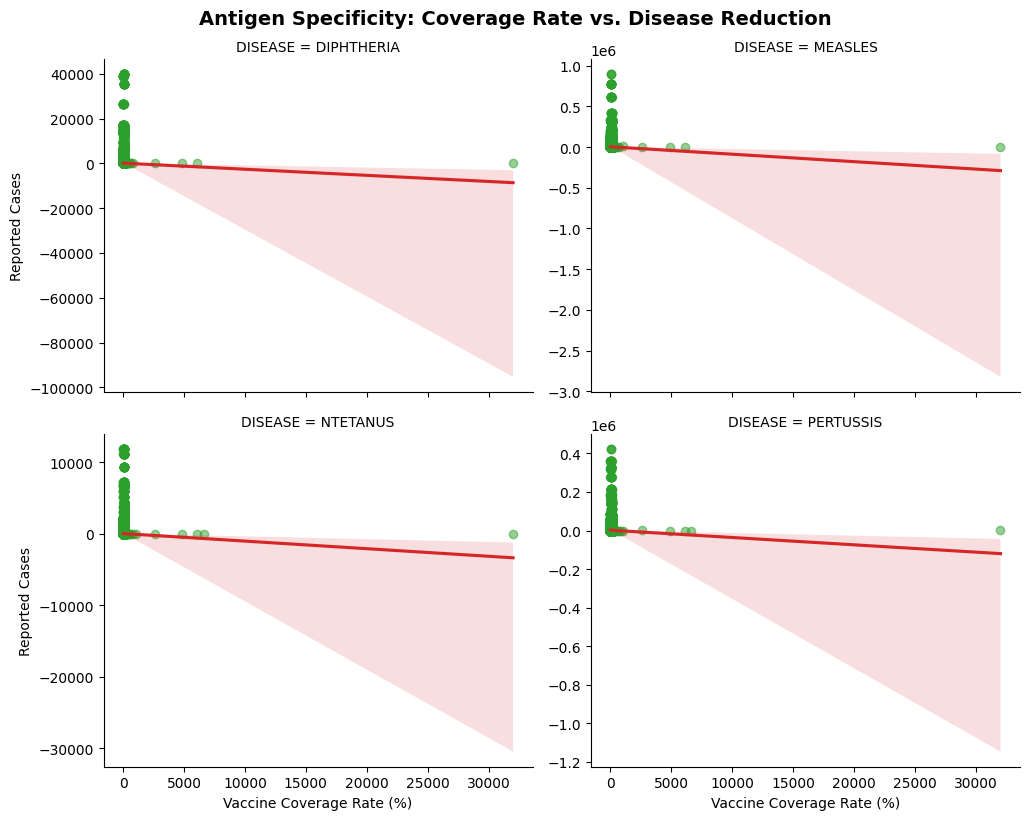

In [14]:
# Merging coverage performance with reported cases matching on Year, Region, and Antigen/Disease
# Assuming a mapping or matching column exists between Vaccine_Type and Disease
merged_antigen = coverage_clean.merge(reported_cases_clean, on=['CODE', 'NAME', 'YEAR'])

# Selecting a few primary antigens to keep the grid readable
target_antigens = merged_antigen['DISEASE'].value_counts().index[:4]
df_filtered = merged_antigen[merged_antigen['DISEASE'].isin(target_antigens)]

g = sns.FacetGrid(df_filtered, col="DISEASE", col_wrap=2, height=4, aspect=1.3, sharey=False, sharex=True)
g.map_dataframe(sns.regplot, x="COVERAGE", y="CASES",
                scatter_kws={'alpha':0.5, 'color': '#2ca02c'}, line_kws={'color': '#d62728'})

g.set_axis_labels("Vaccine Coverage Rate (%)", "Reported Cases")
g.fig.suptitle('Antigen Specificity: Coverage Rate vs. Disease Reduction', fontsize=14, fontweight='bold', y=1.02)
plt.show()

8. Are there specific regions or countries with low coverage despite high availability of vaccines?

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 88.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 67.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 87.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 94.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 90.9% of the points cannot be plac

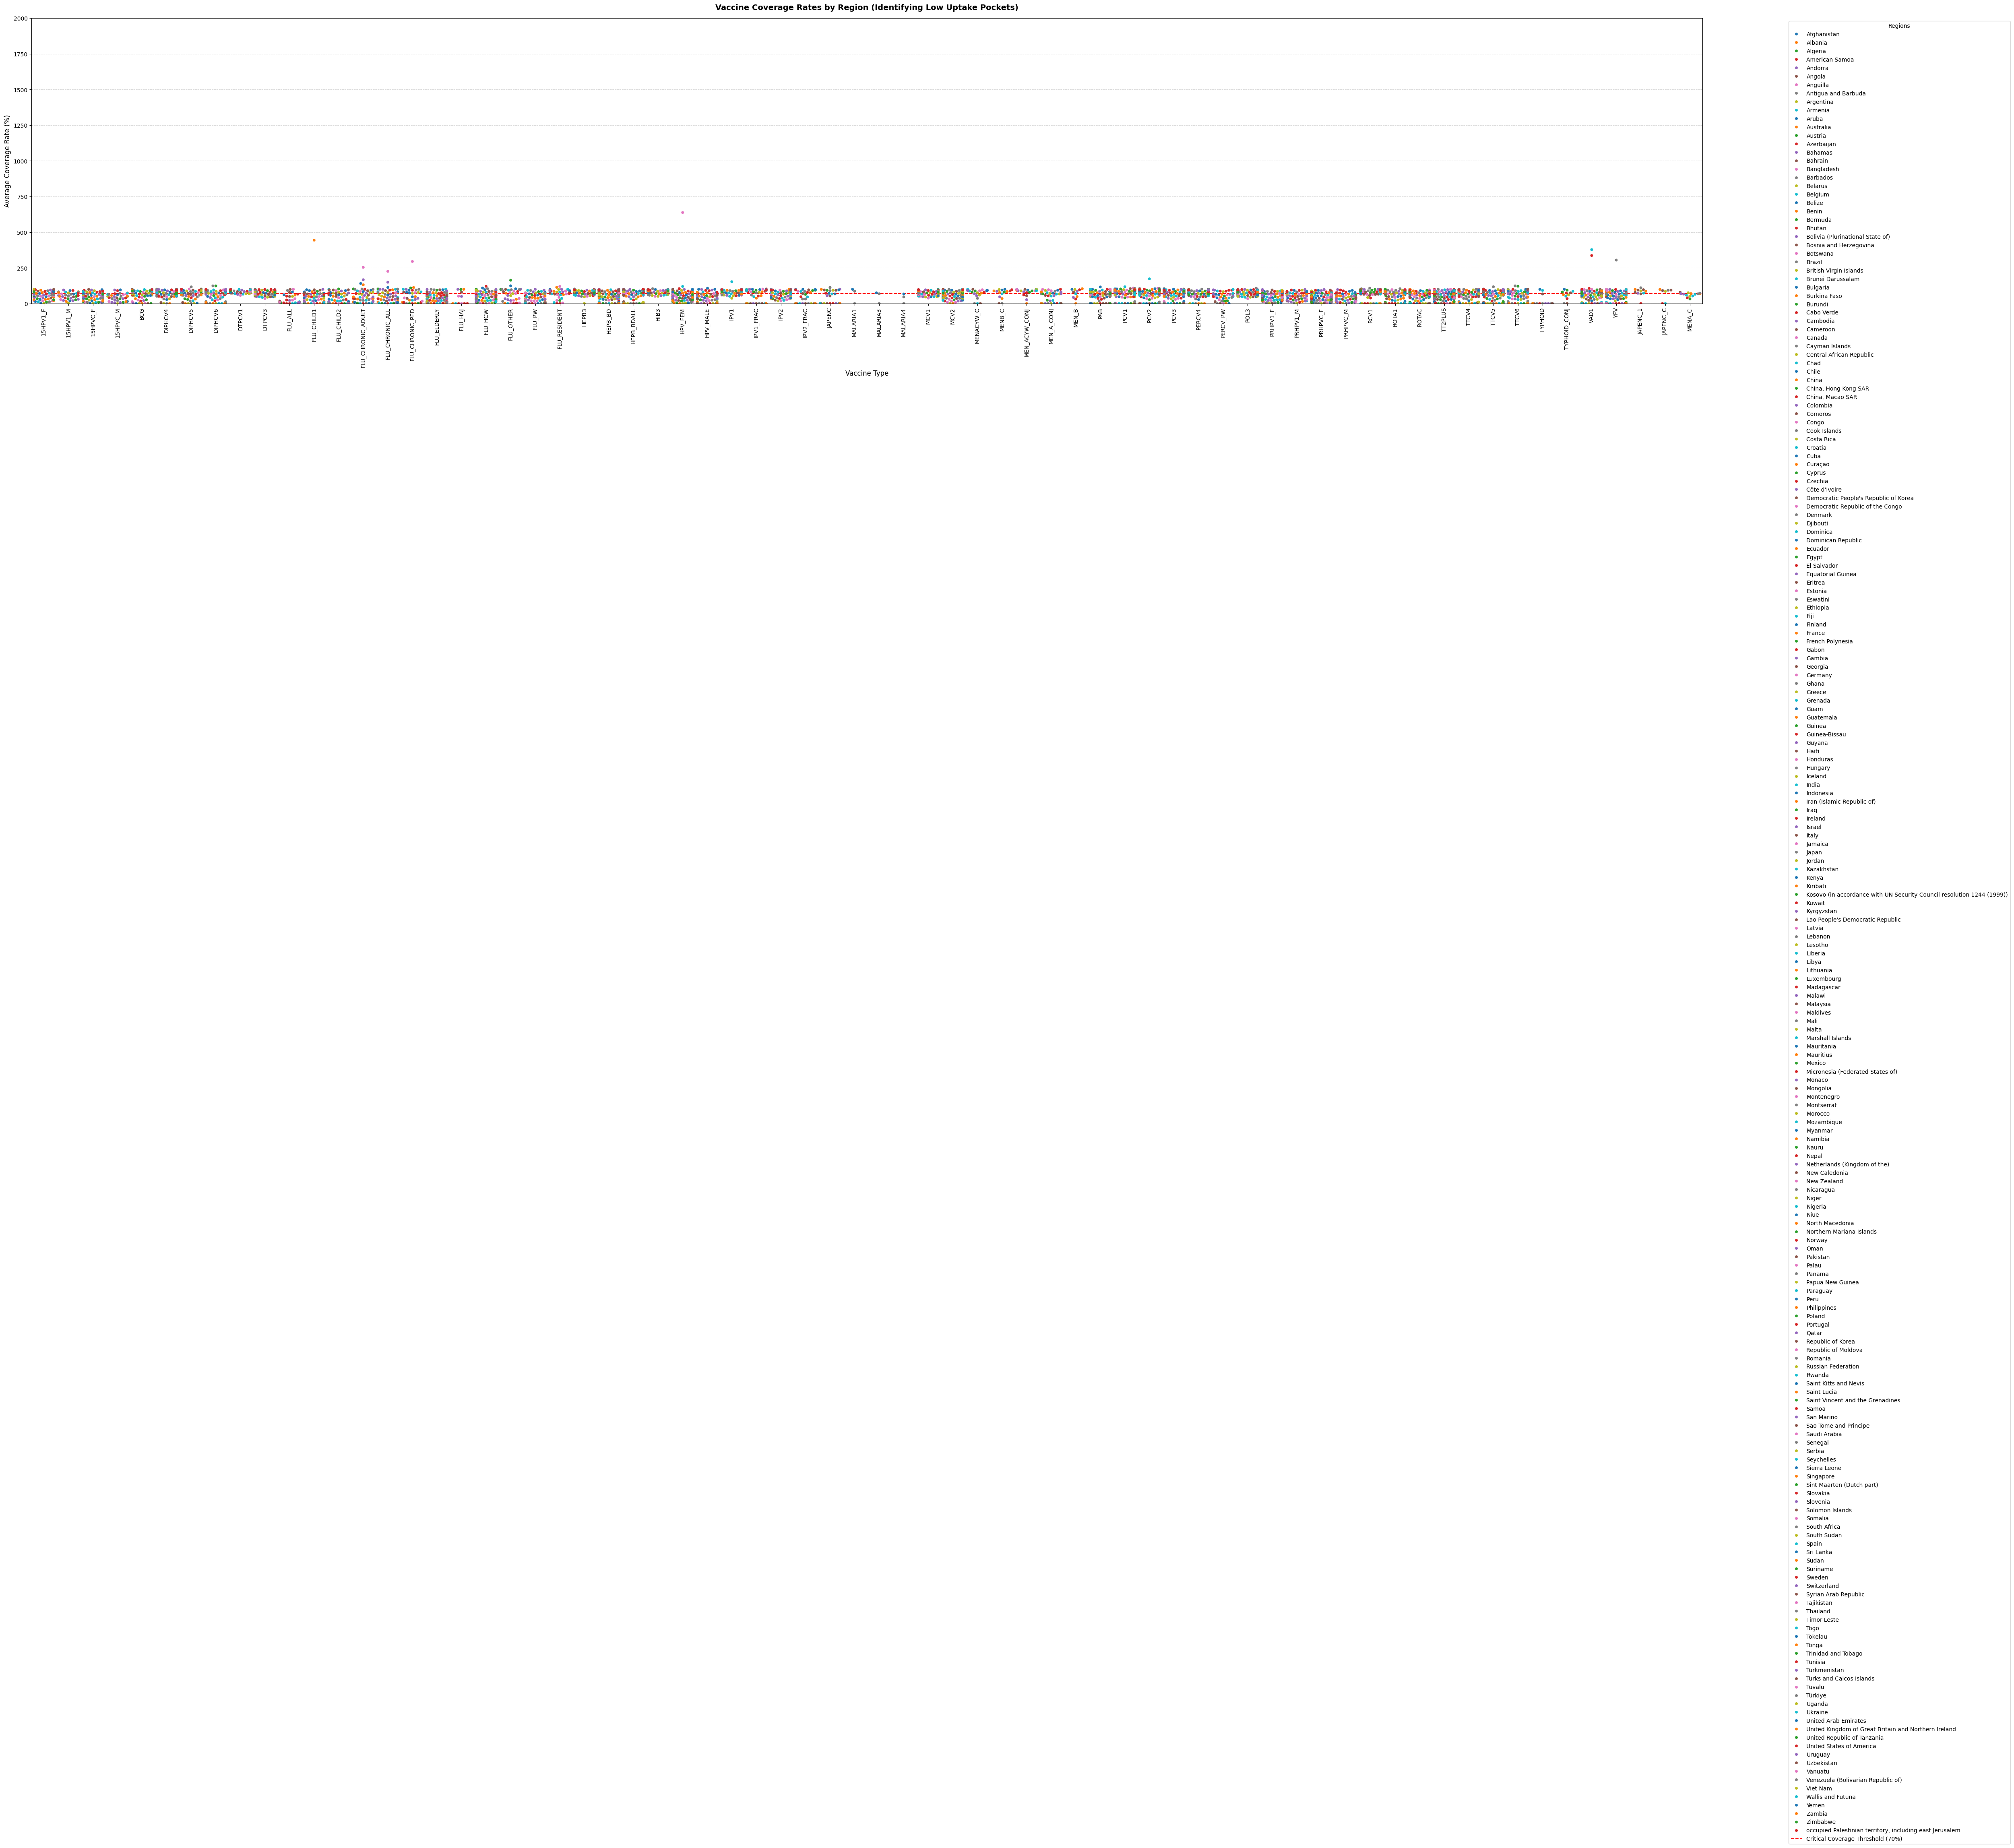

In [15]:
plt.figure(figsize=(50, 30))

# Aggregating average coverage by region/country
availability_coverage = coverage_clean.groupby(['NAME', 'ANTIGEN'])['COVERAGE'].mean().reset_index()

# Plotting distribution
sns.swarmplot(data=availability_coverage, x='ANTIGEN', y='COVERAGE', hue='NAME', palette='tab10')

# Drawing an arbitrary 'Low Coverage' benchmark line (e.g., 70%) to flag anomalies
plt.axhline(y=70, color='red', linestyle='--', linewidth=1.5, label='Critical Coverage Threshold (70%)')

plt.title('Vaccine Coverage Rates by Region (Identifying Low Uptake Pockets)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Vaccine Type', fontsize=12)
plt.xticks(rotation=90)
plt.ylabel('Average Coverage Rate (%)', fontsize=12)
plt.ylim(0, 2000)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Regions')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

9. What are the gaps in coverage for vaccines targeting high-priority diseases (e.g., TB, Hepatitis B)?

/tmp/ipykernel_39997/3785367773.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=gap_data, x='ANTIGEN', y='Coverage_Gap', palette='Reds_r', edgecolor='black')


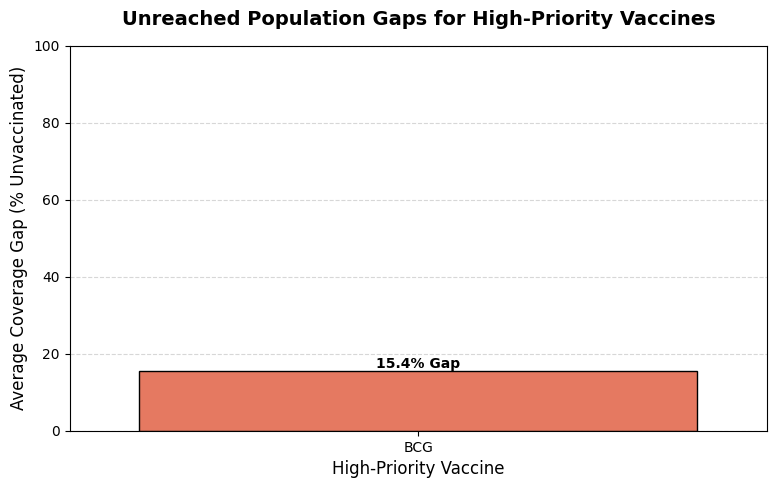

In [16]:
plt.figure(figsize=(9, 5))

# Filter specifically for high-priority diseases/vaccines
priority_vaccines = ['BCG', 'HepB', 'Measles', 'DTP3']
df_priority = coverage_clean[coverage_clean['ANTIGEN'].isin(priority_vaccines)]

# Calculate the gap (100 - Coverage Rate)
gap_data = df_priority.groupby('ANTIGEN')['COVERAGE'].mean().reset_index()
gap_data['Coverage_Gap'] = 100 - gap_data['COVERAGE']
gap_data = gap_data.sort_values(by='Coverage_Gap', ascending=False)

sns.barplot(data=gap_data, x='ANTIGEN', y='Coverage_Gap', palette='Reds_r', edgecolor='black')

# Annotate values
for index, row in gap_data.iterrows():
    plt.text(index, row['Coverage_Gap'] + 1, f"{row['Coverage_Gap']:.1f}% Gap", ha='center', fontweight='bold')

plt.title('Unreached Population Gaps for High-Priority Vaccines', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('High-Priority Vaccine', fontsize=12)
plt.ylabel('Average Coverage Gap (% Unvaccinated)', fontsize=12)
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

10. Are certain diseases more prevalent in specific geographic areas?

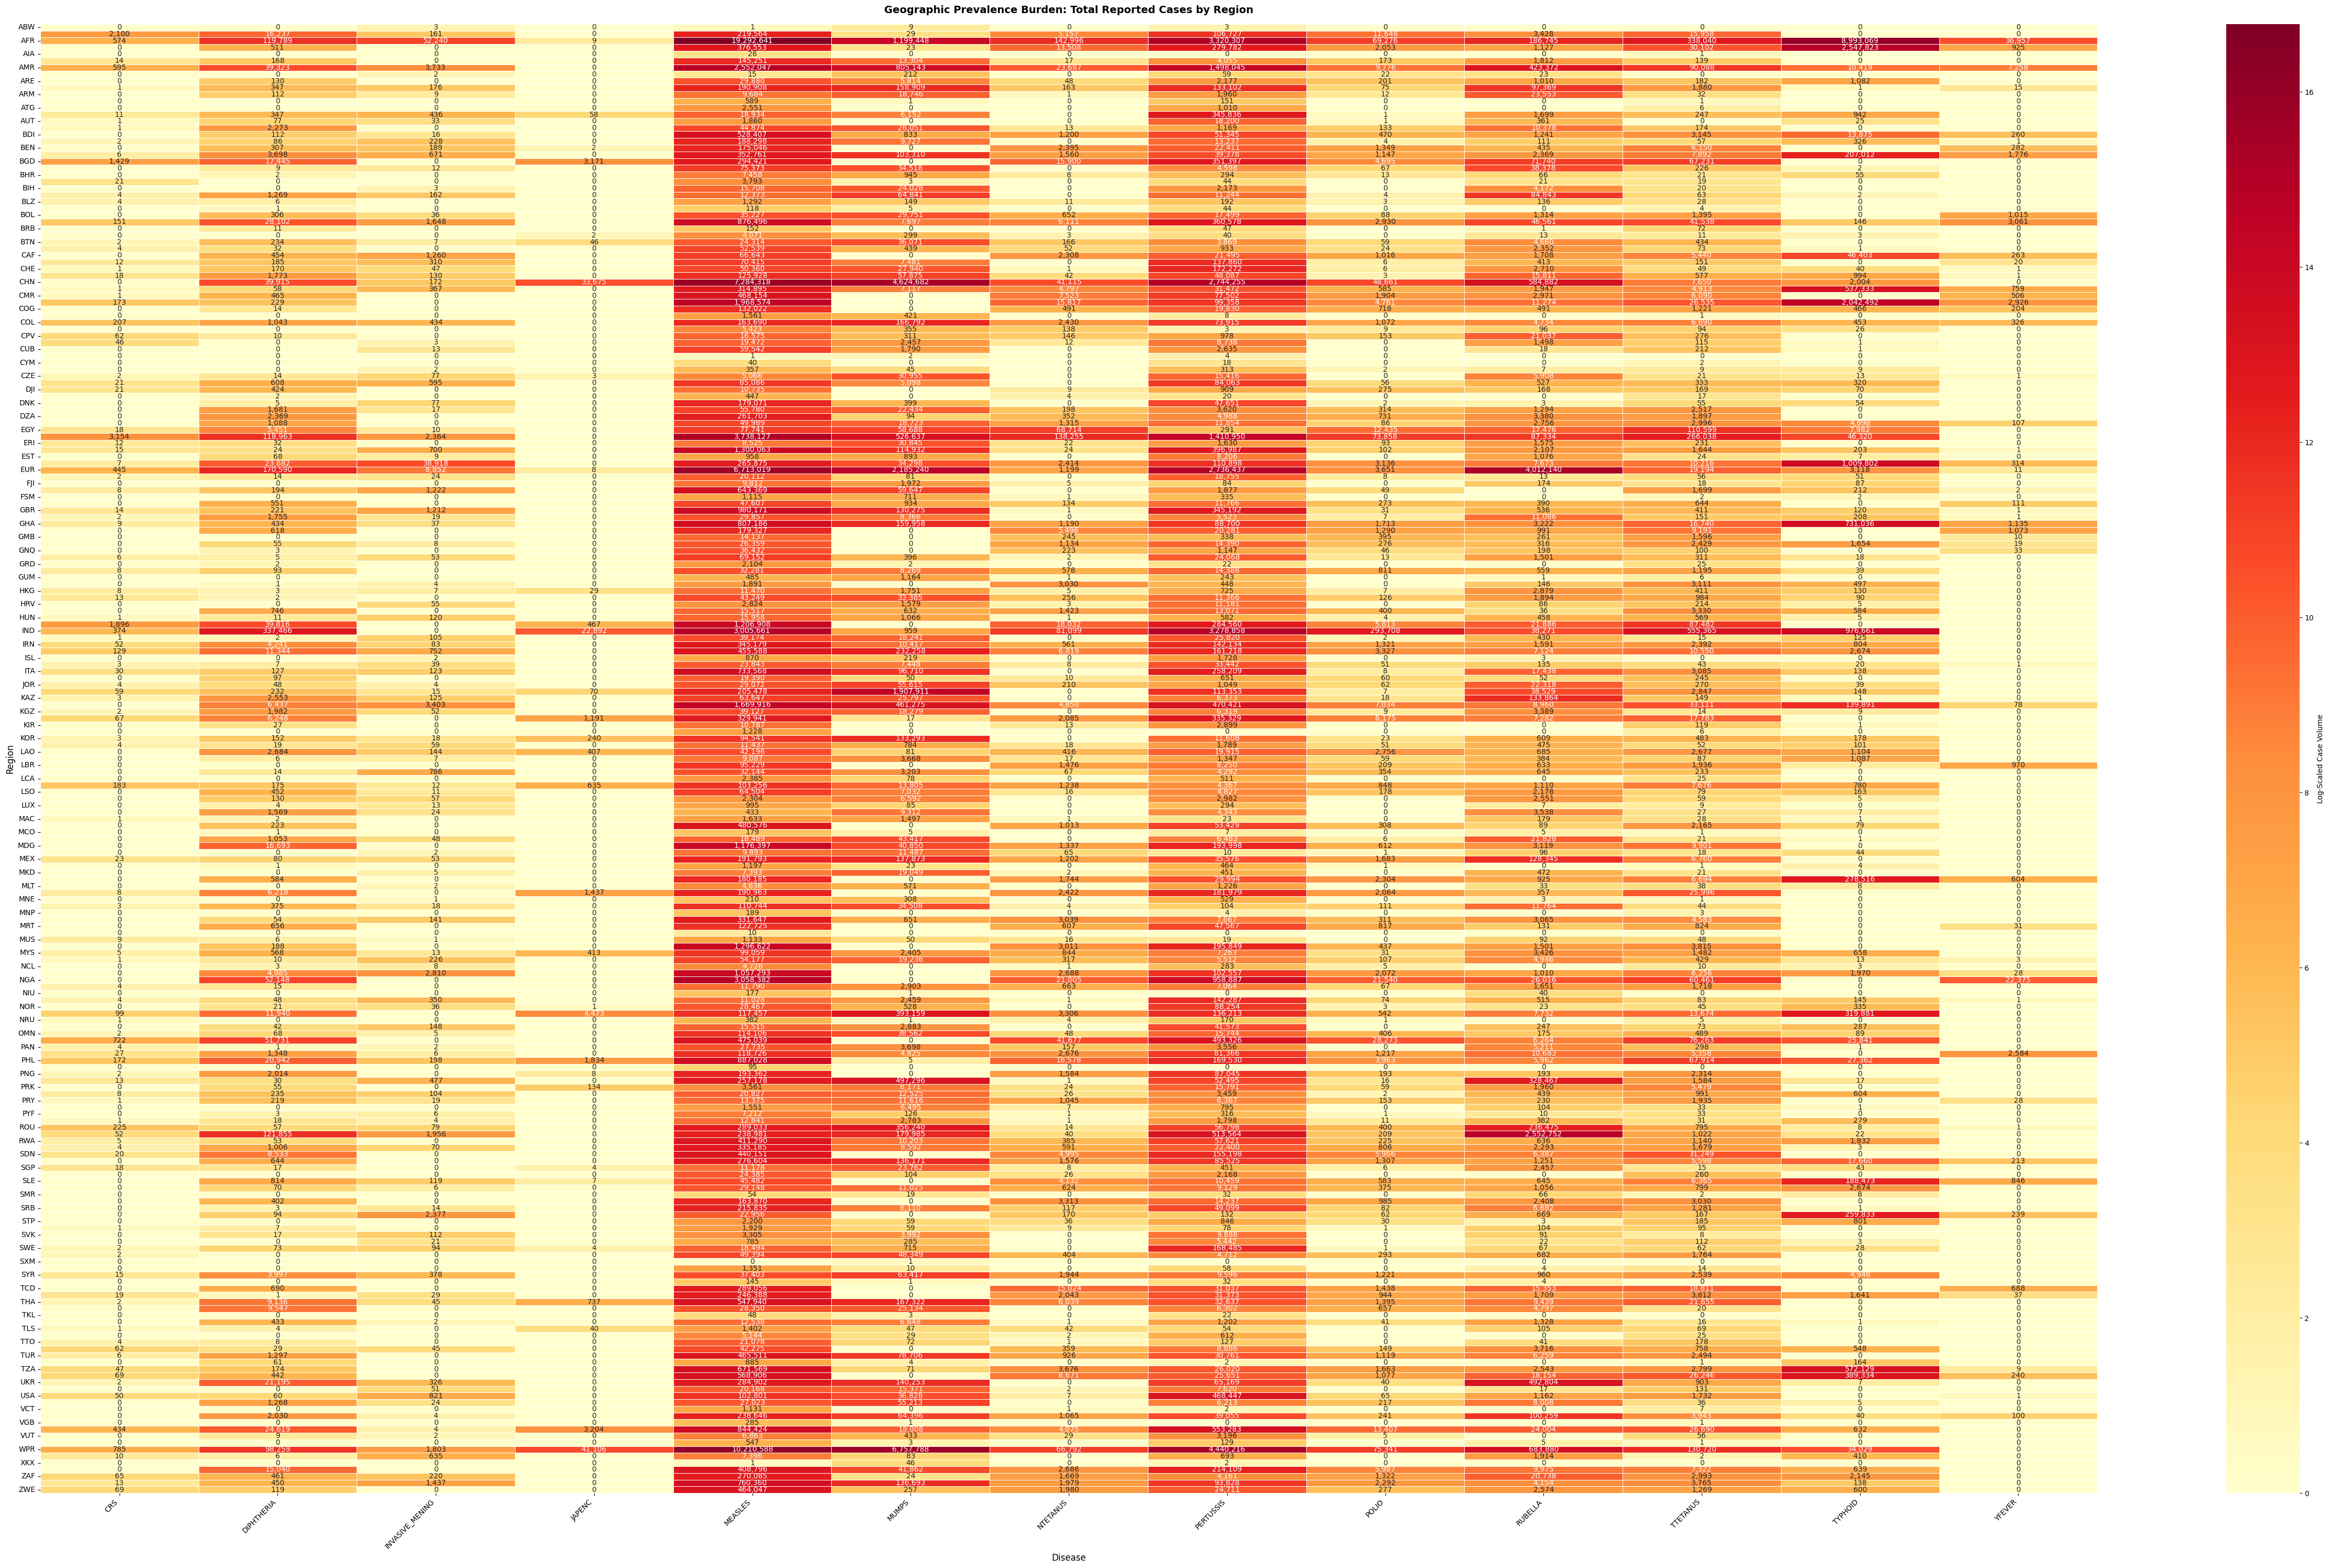

In [17]:
plt.figure(figsize=(50, 30))

# Create a pivot table of total cases by Region and Disease
geo_prevalence = reported_cases_clean.pivot_table(
    index='CODE',
    columns='DISEASE',
    values='CASES',
    aggfunc='sum',
    fill_value=0
)

# Using a log scale log1p (log(1+x)) for the heatmap color gradient if case volumes vary drastically
import numpy as np
sns.heatmap(np.log1p(geo_prevalence), annot=geo_prevalence, fmt=",.0f", cmap='YlOrRd',
            cbar_kws={'label': 'Log-Scaled Case Volume'}, linewidths=0.5)

plt.title('Geographic Prevalence Burden: Total Reported Cases by Region', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Disease', fontsize=12)
plt.ylabel('Region', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#**Scenario based:**

1. A government health agency wants to identify regions with low vaccination coverage to allocate resources effectively.

/tmp/ipykernel_39997/4277735827.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=priority_regions, x='COVERAGE', y='NAME', palette=colors, edgecolor='black')


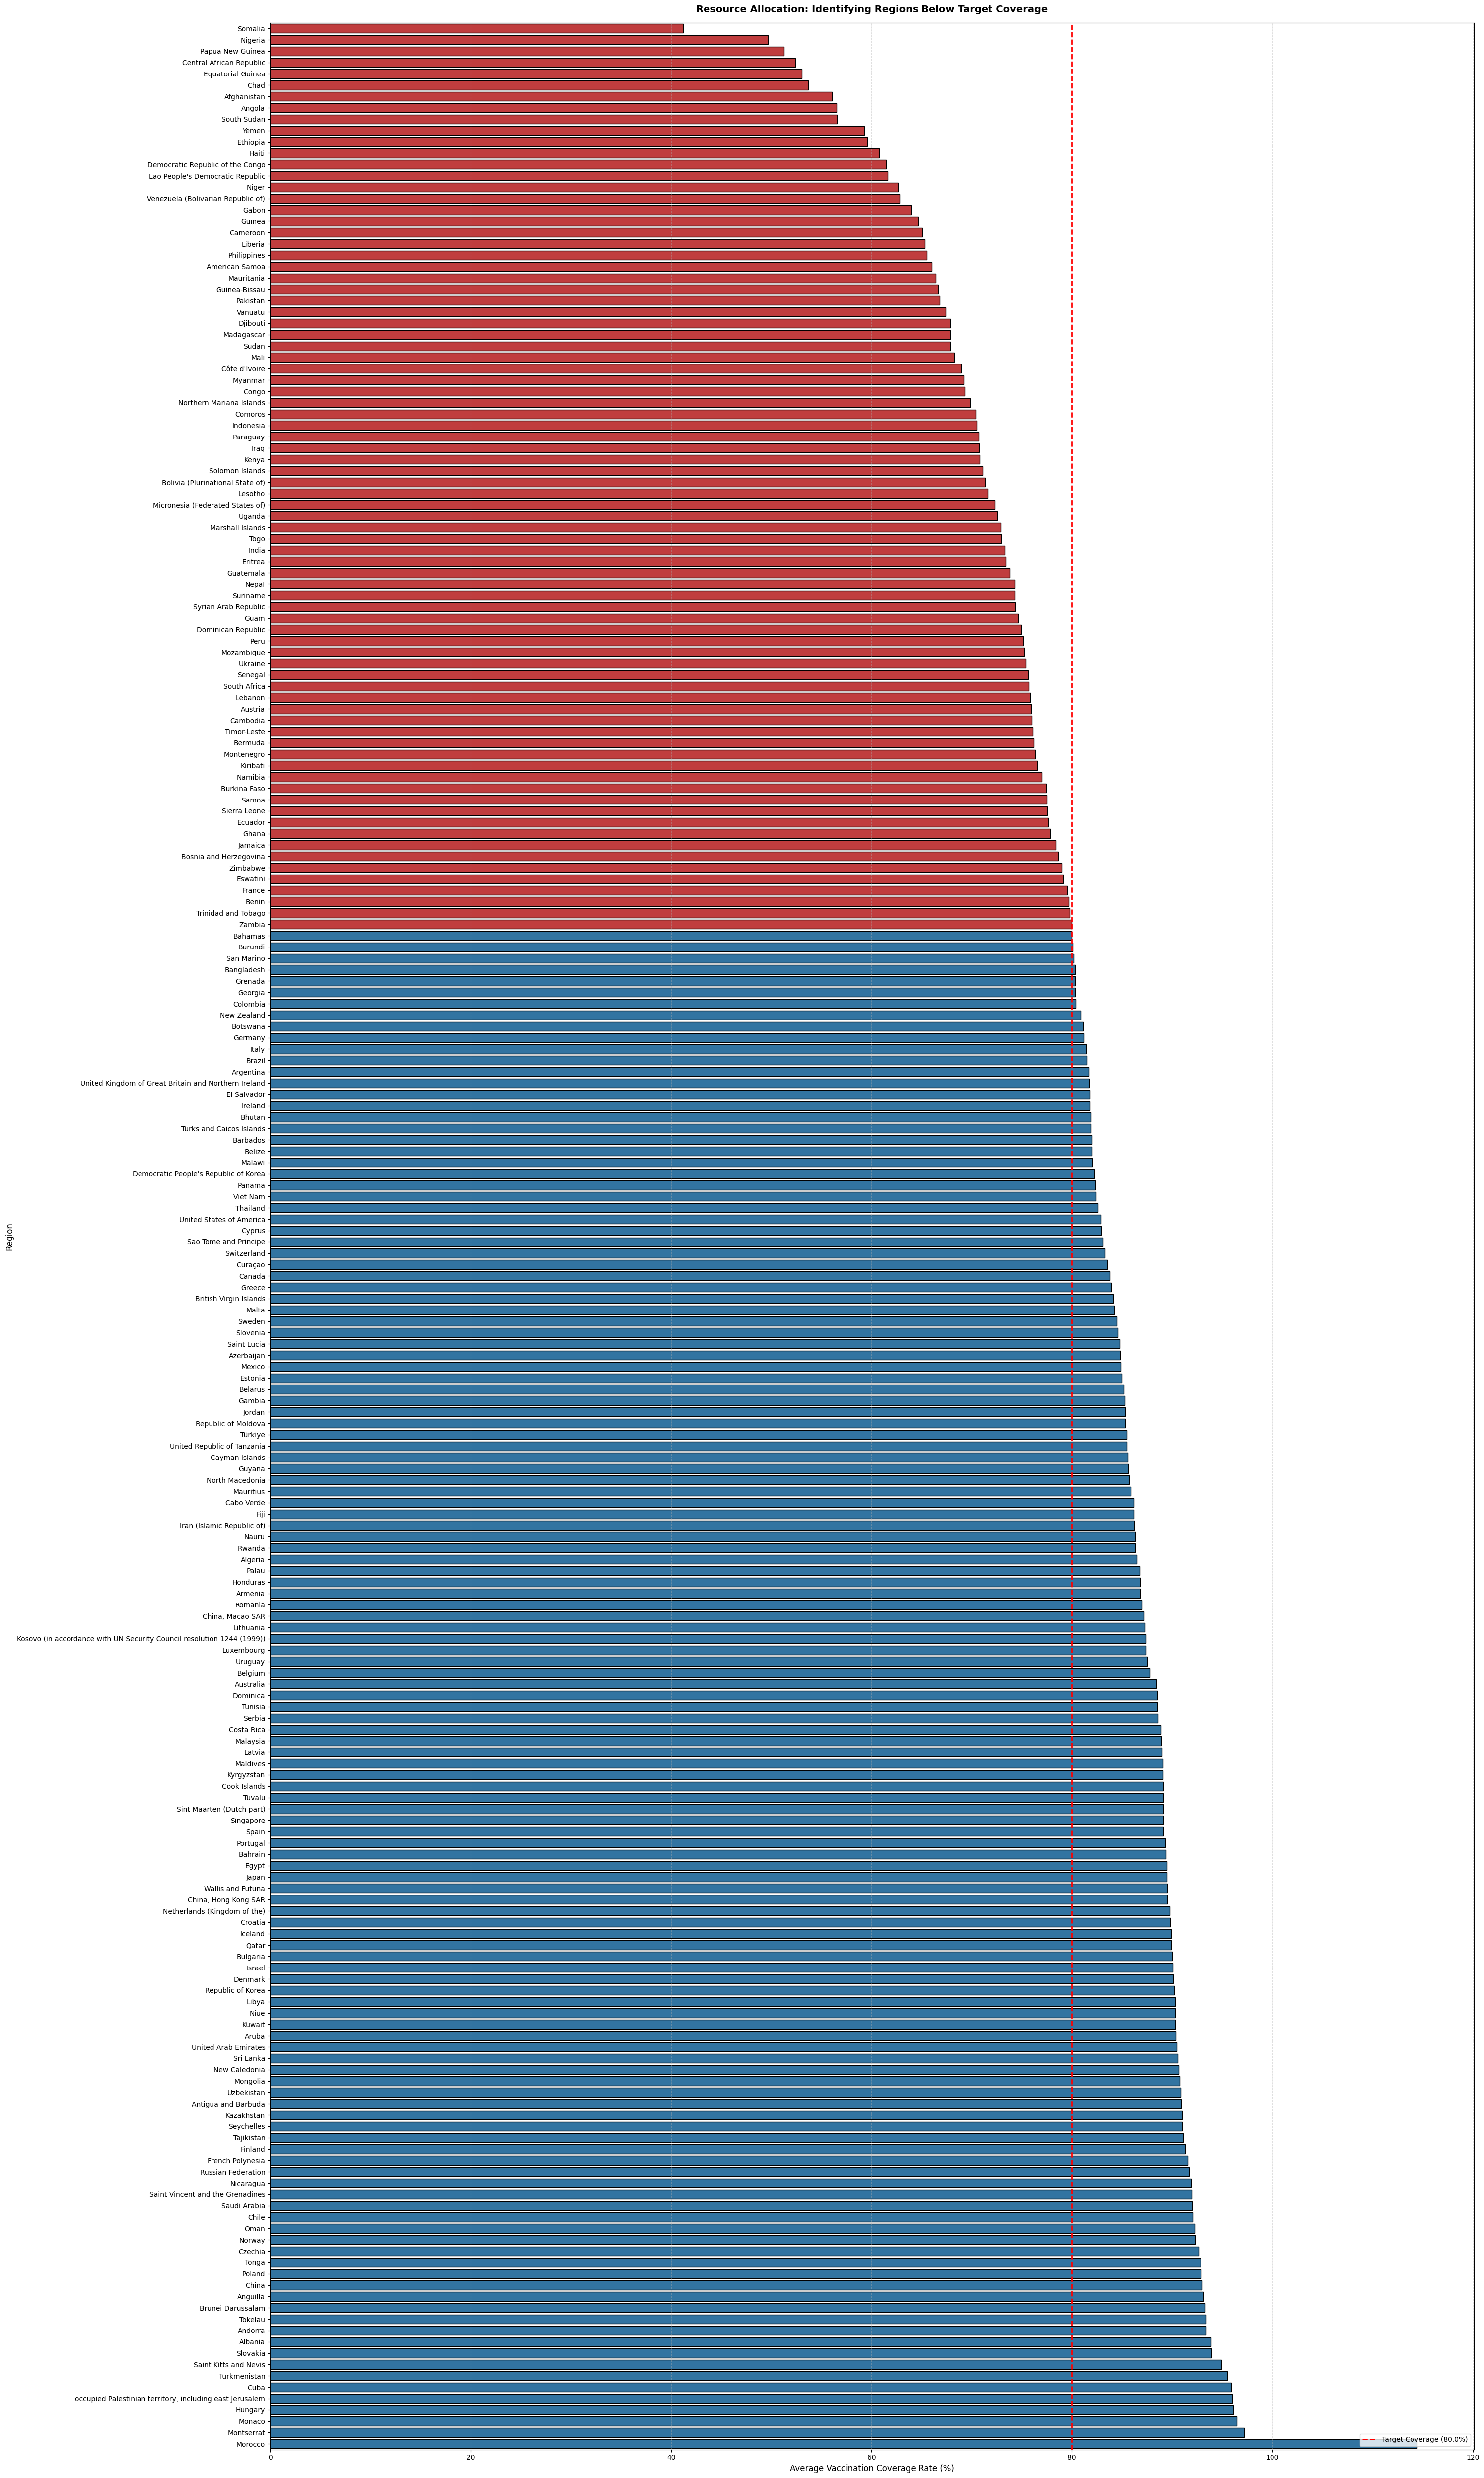

In [18]:
plt.figure(figsize=(30, 50))

# Aggregating the lowest performing regions based on recent data
priority_regions = coverage_clean.groupby('NAME')['COVERAGE'].mean().reset_index()
priority_regions = priority_regions.sort_values(by='COVERAGE')

# Color coding bars: Red for below threshold, Blue for safe zones
threshold = 80.0
colors = ['#d62728' if rate < threshold else '#1f77b4' for rate in priority_regions['COVERAGE']]

sns.barplot(data=priority_regions, x='COVERAGE', y='NAME', palette=colors, edgecolor='black')

# Add a critical threshold line for resource allocation
plt.axvline(x=threshold, color='red', linestyle='--', linewidth=2, label=f'Target Coverage ({threshold}%)')

plt.title('Resource Allocation: Identifying Regions Below Target Coverage', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Average Vaccination Coverage Rate (%)', fontsize=12)
plt.ylabel('Region', fontsize=12)
plt.legend(loc='lower right')
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

2. A public health organization wants to evaluate the effectiveness of a measles vaccination campaign launched five years ago.

<Figure size 2500x500 with 0 Axes>

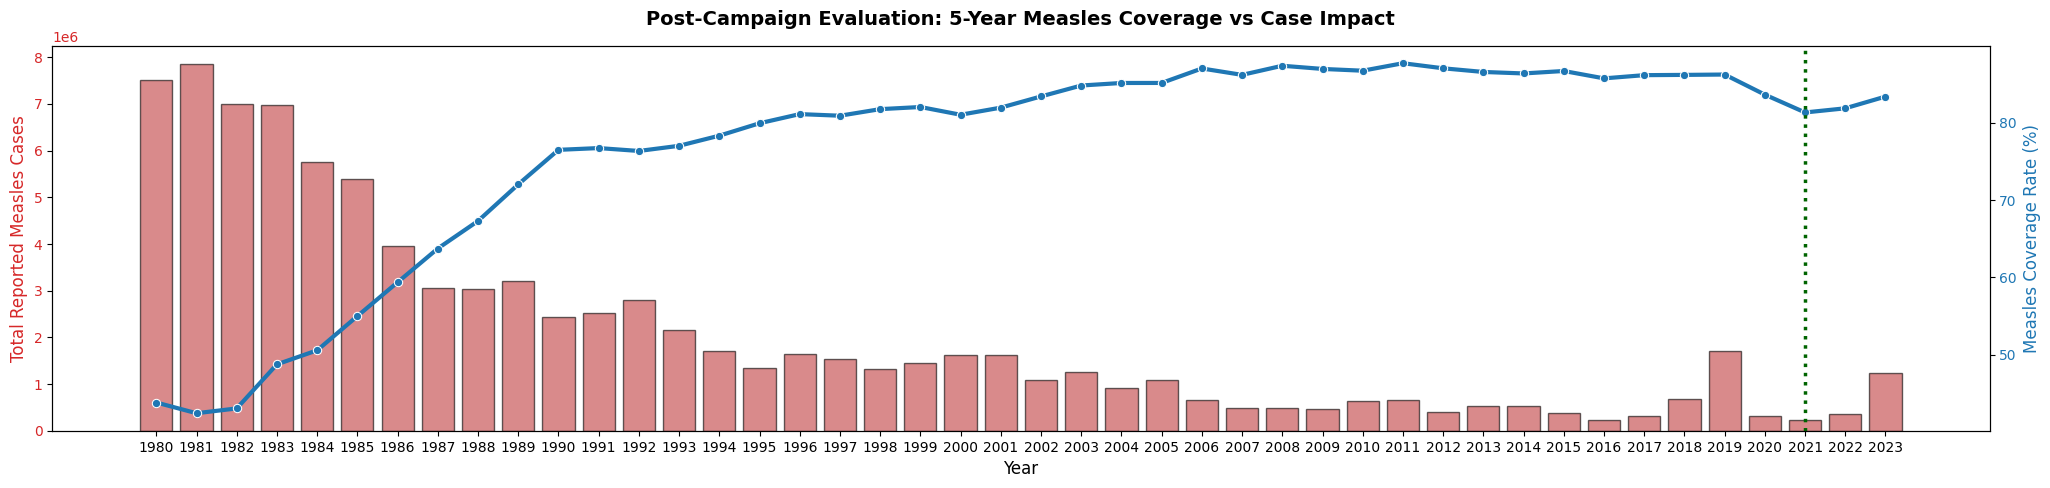

In [19]:
plt.figure(figsize=(25, 5))

# Filter specifically for Measles data
measles_cases = reported_cases_clean[reported_cases_clean['DISEASE'] == 'MEASLES'].groupby('YEAR')['CASES'].sum().reset_index()
measles_cov = coverage_clean[coverage_clean['ANTIGEN_DESCRIPTION'].str.contains('Measles')].groupby('YEAR')['COVERAGE'].mean().reset_index()
measles_trend = measles_cases.merge(measles_cov, on='YEAR')

fig, ax1 = plt.subplots(figsize=(25, 5))

# Plotting Case Volumes (Bar chart)
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Total Reported Measles Cases', color='#d62728', fontsize=12)
sns.barplot(data=measles_trend, x='YEAR', y='CASES', ax=ax1, color='#d62728', alpha=0.6, edgecolor='black')
ax1.tick_params(axis='y', labelcolor='#d62728')

# Overlaying Coverage Rate (Line chart)
ax2 = ax1.twinx()
ax2.set_ylabel('Measles Coverage Rate (%)', color='#1f77b4', fontsize=12)
sns.lineplot(data=measles_trend, x=range(len(measles_trend)), y='COVERAGE', ax=ax2, color='#1f77b4', marker='o', linewidth=3)
ax2.tick_params(axis='y', labelcolor='#1f77b4')

# Highlighting the campaign benchmark year (5 years ago, relative to data)
# Adjust the index matching your specific campaign start year
campaign_year_label = "2021"
if campaign_year_label in measles_trend['YEAR'].astype(str).values:
    campaign_idx = measles_trend[measles_trend['YEAR'].astype(str) == campaign_year_label].index[0]
    plt.axvline(x=campaign_idx, color='darkgreen', linestyle=':', linewidth=2.5, label='Campaign Launch')

plt.title('Post-Campaign Evaluation: 5-Year Measles Coverage vs Case Impact', fontsize=14, fontweight='bold', pad=15)
plt.show()

3. A vaccine manufacturer wants to estimate vaccine demand for a specific disease in the upcoming year.

/tmp/ipykernel_39997/2077717674.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=demand_forecast, x='UNREACHED_POPULATION', y='ANTIGEN_DESCRIPTION', palette='Blues_r', edgecolor='black')


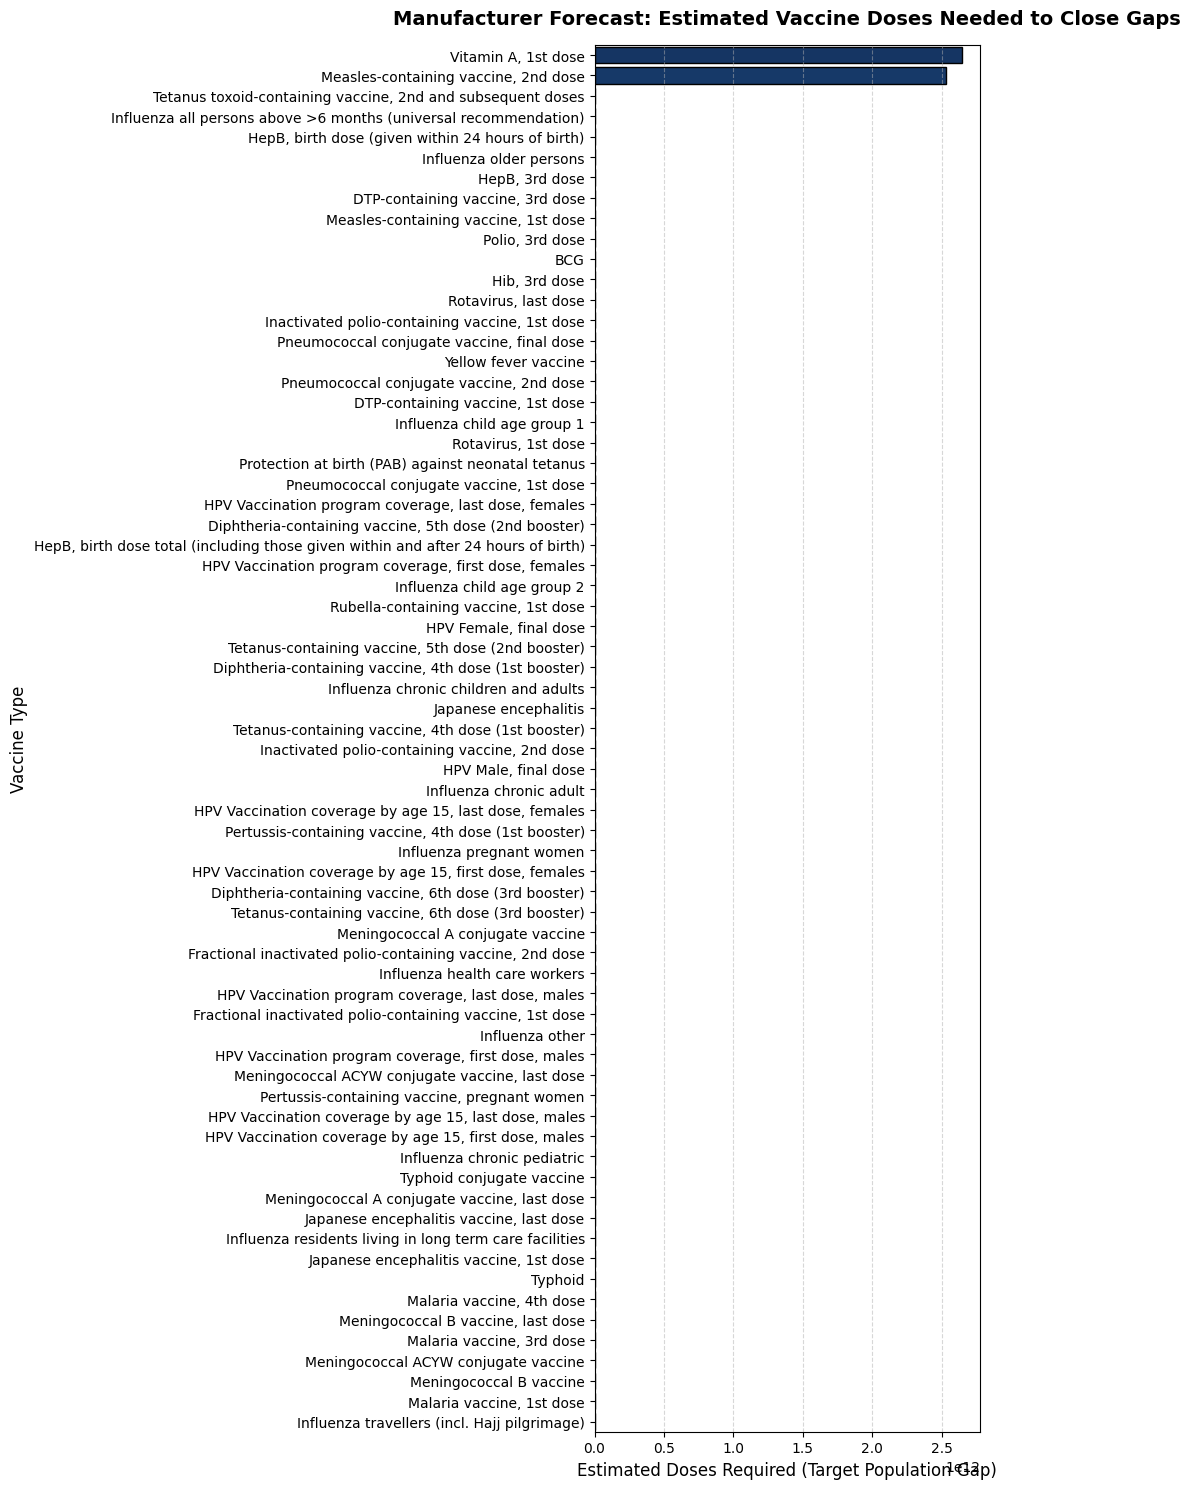

In [20]:
plt.figure(figsize=(10, 15))

# Formula: Demand = Target Population * (Desired Target Coverage - Current Coverage)
# For simplicity, calculating the size of the unreached population cohort
coverage_clean['UNREACHED_POPULATION'] = coverage_clean['TARGET_NUMBER'] * (1 - (coverage_clean['COVERAGE'] / 100))

# Group by target disease/vaccine to show manufacturing scale requirements
demand_forecast = coverage_clean.groupby('ANTIGEN_DESCRIPTION')['UNREACHED_POPULATION'].sum().reset_index()
demand_forecast = demand_forecast.sort_values(by='UNREACHED_POPULATION', ascending=False)

sns.barplot(data=demand_forecast, x='UNREACHED_POPULATION', y='ANTIGEN_DESCRIPTION', palette='Blues_r', edgecolor='black')

plt.title('Manufacturer Forecast: Estimated Vaccine Doses Needed to Close Gaps', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Estimated Doses Required (Target Population Gap)', fontsize=12)
plt.ylabel('Vaccine Type', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

4. A sudden outbreak of influenza occurs in a specific region, and authorities need to ramp up vaccination efforts.

Answer: No data provided for disease sudden outbreak and tracking

5. Researchers want to explore the incidence rates of polio in populations with no vaccination coverage.

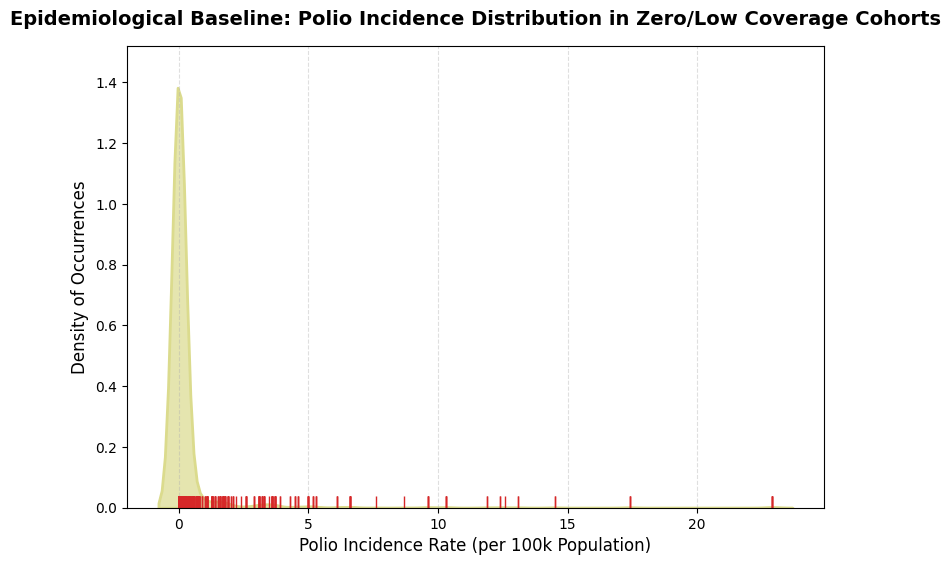

In [21]:
plt.figure(figsize=(9, 6))

# Filtering down to low/no vaccine coverage thresholds (<20%) to isolate control/baseline behaviors
baseline_research = merged_data[(merged_data['DISEASE'] == 'POLIO') & (merged_data['COVERAGE'] < 20)]

sns.kdeplot(data=baseline_research, x='INCIDENCE_RATE', fill=True, color='#dbdb8d', alpha=0.7, linewidth=2)
sns.rugplot(data=baseline_research, x='INCIDENCE_RATE', color='#d62728')

plt.title('Epidemiological Baseline: Polio Incidence Distribution in Zero/Low Coverage Cohorts', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Polio Incidence Rate (per 100k Population)', fontsize=12)
plt.ylabel('Density of Occurrences', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.show()

6. WHO wants to track global progress toward achieving a target of 95% vaccination coverage for measles by 2030.

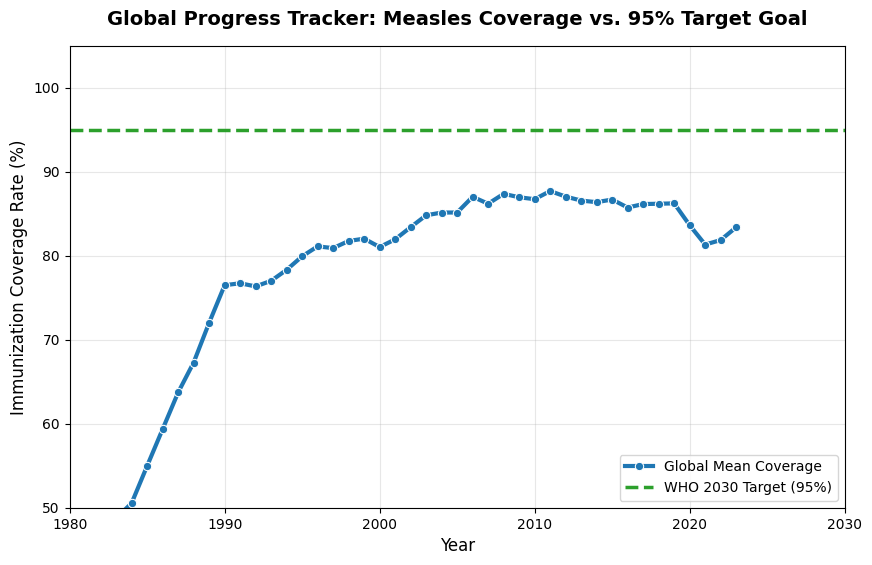

In [22]:
plt.figure(figsize=(10, 6))

# Aggregating global average coverage for Measles over the years
measles_global = coverage_clean[coverage_clean['ANTIGEN_DESCRIPTION'].str.contains('Measles')].groupby('YEAR')['COVERAGE'].mean().reset_index()

# Plotting historical progress
sns.lineplot(data=measles_global, x='YEAR', y='COVERAGE', color='#1f77b4', marker='o', linewidth=3, label='Global Mean Coverage')

# Adding the 95% WHO Target Line extending across the timeline axis
plt.axhline(y=95, color='#2ca02c', linestyle='--', linewidth=2.5, label='WHO 2030 Target (95%)')

# Setting up limits to visualize the trajectory toward 2030
current_max_year = measles_global['YEAR'].max()
plt.xlim(measles_global['YEAR'].min(), 2030)
plt.ylim(50, 105)

plt.title('Global Progress Tracker: Measles Coverage vs. 95% Target Goal', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Immunization Coverage Rate (%)', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

7. A health agency wants to allocate vaccines to high-risk populations such as children under five and the elderly.

Answer: No proper Age Distribution data is provided.

8. A non-profit wants to detect disparities in vaccination coverage across different socioeconomic groups within a country.

Answer: No Socioeconomic groups data is provided.

9. Authorities want to determine how vaccination rates vary throughout the year.

Answer: No data about variation in vaccine throughout the year is provided.

10. Two regions use different vaccination strategies (e.g., door-to-door vs. centralized vaccination clinics). Authorities want to know which strategy is more effective.

Answer: No data about Distribution Strategy is provided.